In [ ]:
#imports
import torch
import torchvision
from torchvision.transforms import v2
from torch.utils.data import DataLoader, random_split
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import models

In [28]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support



In [3]:
device = torch.device(
    torch.accelerator.current_accelerator().type
    if torch.accelerator.is_available()
    else 'cpu'
)

print(device)

cuda


In [7]:

#create transform for images and normalize
transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize((0.5, 0.5, 0.5),
                 (0.5, 0.5, 0.5))
])

#set batch size to 4
batch_size = 4

#download dataset and apply transform
dataset = torchvision.datasets.EuroSAT(
    root='./data',
    download=True,
    transform=transform
)

#80% train, 20% test
train_size = int(0.7 * len(dataset))
test_size = int(0.15 * len(dataset))
val_size = int(0.15 * len(dataset))

#split data
generator = torch.Generator().manual_seed(42)

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size],
    generator=generator
)

#final data prep
trainloader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2
)

valloader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=True
)

testloader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)

#set classes
classes = (
    'AnnualCrop',
    'Forest',
    'HerbaceousVegetation',
    'Highway',
    'Industrial',
    'Pasture',
    'PermanentCrop',
    'Residential',
    'River',
    'SeaLake'
    )

In [8]:
#define CNN
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, 3,padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, 3,padding=1)
        self.fc1 = nn.Linear(32 * 16 * 16, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1) # flatten all dimensions except batch
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


net = Net()

In [ ]:
#loss and optimizer definitiom
criterion_new = nn.CrossEntropyLoss()
optimizer_new = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

In [ ]:
#Keep In code to show preliminary idea, but function below much more efficient
"""
train_accuracies = []
val_accuracies = []

#Train Network
for epoch in range(2):  # loop over the dataset multiple times
    net.train()

    running_loss = 0.0

    for i, data in enumerate(trainloader, 0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        if i % 2000 == 1999:    # print every 2000 mini-batches
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
            running_loss = 0.0

    # evaluate after this epoch
    eval(trainloader, train_accuracies)
    eval(valloader, val_accuracies)

print('Finished Training')
"""

[1,  2000] loss: 0.810
[1,  4000] loss: 0.735

Epoch 1 Training:
Accuracy for class: AnnualCrop is 82.3 %
Accuracy for class: Forest is 94.6 %
Accuracy for class: HerbaceousVegetation is 68.8 %
Accuracy for class: Highway is 66.0 %
Accuracy for class: Industrial is 89.8 %
Accuracy for class: Pasture is 70.7 %
Accuracy for class: PermanentCrop is 66.0 %
Accuracy for class: Residential is 93.1 %
Accuracy for class: River is 74.2 %
Accuracy for class: SeaLake is 85.1 %
Overall Accuracy: 79.8 %

Epoch 1 Validation:
Accuracy for class: AnnualCrop is 78.3 %
Accuracy for class: Forest is 93.7 %
Accuracy for class: HerbaceousVegetation is 64.7 %
Accuracy for class: Highway is 55.4 %
Accuracy for class: Industrial is 86.6 %
Accuracy for class: Pasture is 74.1 %
Accuracy for class: PermanentCrop is 61.9 %
Accuracy for class: Residential is 89.9 %
Accuracy for class: River is 65.4 %
Accuracy for class: SeaLake is 81.0 %
Overall Accuracy: 75.5 %
[2,  2000] loss: 0.630
[2,  4000] loss: 0.616

Epoch

In [ ]:
#much more efficient than training above - this can be used for all models
def train_model(model, trainloader, criterion, optimizer, tracker, epochs=10):

    for epoch in range(epochs):

        # Put model in training mode
        model.train()

        running_loss = 0.0

        # Store all labels and predictions
        all_labels = []
        all_preds = []

        # Count correct and total predictions for each class
        correct_pred = {classname: 0 for classname in classes}
        total_pred = {classname: 0 for classname in classes}

        # Count correct and total predictions overall
        total_correct = 0
        total = 0

        for images, labels in trainloader:

            images = images.to(device)
            labels = labels.to(device)

            # Reset gradients from previous batch
            optimizer.zero_grad()

            # Forward pass
            outputs = model(images)

            # Calculate loss
            loss = criterion(outputs, labels)

            # Calculate gradients
            loss.backward()

            # Update trainable weights
            optimizer.step()

            # Track loss
            running_loss += loss.item()

            # Get predicted classes
            _, predictions = torch.max(outputs, 1)

            # Count overall correct predictions
            total_correct += (predictions == labels).sum().item()
            total += labels.size(0)

            # Store labels and predictions
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predictions.cpu().numpy())

            # Count correct predictions for each class
            for label, prediction in zip(labels, predictions):
                if label == prediction:
                    correct_pred[classes[label]] += 1
                total_pred[classes[label]] += 1

        # Calculate overall accuracy
        overall_accuracy = 100 * total_correct / total

        # Calculate precision, recall, F1, and support for each class
        class_precision, class_recall, class_f1, support = precision_recall_fscore_support(
            all_labels,
            all_preds,
            average=None,
            labels=range(10),
            zero_division=0
        )

        # Convert class metrics to percentages
        class_precision = class_precision * 100
        class_recall = class_recall * 100
        class_f1 = class_f1 * 100

        # Calculate overall macro precision, recall, and F1
        overall_precision = class_precision.mean()
        overall_recall = class_recall.mean()
        overall_f1 = class_f1.mean()

        # Store accuracy for each class
        class_accuracy = []

        # Calculate accuracy for each class
        for classname in classes:
            accuracy = 100 * correct_pred[classname] / total_pred[classname]
            class_accuracy.append(accuracy)

        # Calculate average loss
        average_loss = running_loss / len(trainloader)

        # Store all training metrics for this epoch
        tracker.append([
            average_loss,
            overall_accuracy,
            overall_precision,
            overall_recall,
            overall_f1,
            class_accuracy,
            class_precision.tolist(),
            class_recall.tolist(),
            class_f1.tolist(),
            support.tolist()
        ])

        # Print loss for debugging
        print(
            f"Epoch {epoch + 1}/{epochs}, "
            f"Loss: {average_loss:.4f}"
        )

    return model

In [ ]:
def eval(model, loader, tracker):
    model.eval()

    # Count correct and total predictions for each class
    correct_pred = {classname: 0 for classname in classes}
    total_pred = {classname: 0 for classname in classes}

    # Count correct and total predictions overall
    total_correct = 0
    total = 0

    # Store all labels and predictions
    all_labels = []
    all_preds = []

    # Turn off gradient calculations
    with torch.no_grad():
        for data in loader:
            images, labels = data

            # Move data to same device as model
            images = images.to(device)
            labels = labels.to(device)

            # Get model outputs and predicted classes
            outputs = model(images)
            _, predictions = torch.max(outputs, 1)

            # Count overall correct predictions
            total_correct += (predictions == labels).sum().item()
            total += labels.size(0)

            # Store labels and predictions
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predictions.cpu().numpy())

            # Count correct predictions for each class
            for label, prediction in zip(labels, predictions):
                if label == prediction:
                    correct_pred[classes[label]] += 1
                total_pred[classes[label]] += 1

    # Calculate overall accuracy
    overall_accuracy = 100 * total_correct / total

    # Calculate precision, recall, F1, and support for each class
    class_precision, class_recall, class_f1, support = precision_recall_fscore_support(
        all_labels,
        all_preds,
        average=None,
        labels=range(10),
        zero_division=0
    )

    # Convert class metrics to percentages
    class_precision = class_precision * 100
    class_recall = class_recall * 100
    class_f1 = class_f1 * 100

    # Calculate overall macro precision, recall, and F1
    overall_precision = class_precision.mean()
    overall_recall = class_recall.mean()
    overall_f1 = class_f1.mean()

    # Store accuracy for each class
    class_accuracy = []

    # Calculate accuracy for each class
    for classname in classes:
        accuracy = 100 * correct_pred[classname] / total_pred[classname]
        class_accuracy.append(accuracy)

    # Store all evaluation metrics in tracker
    tracker.append([
        overall_accuracy,
        overall_precision,
        overall_recall,
        overall_f1,
        class_accuracy,
        class_precision.tolist(),
        class_recall.tolist(),
        class_f1.tolist(),
        support.tolist()
    ])

    # Return overall accuracy
    return overall_accuracy

In [ ]:
#Function to plot tracked data
def plot_tracker(tracker, model_name):

    # Create epoch numbers
    epochs = range(1, len(tracker) + 1)

    # Get overall metrics from each epoch
    losses = [results[0] for results in tracker]
    accuracies = [results[1] for results in tracker]
    precisions = [results[2] for results in tracker]
    recalls = [results[3] for results in tracker]
    f1_scores = [results[4] for results in tracker]

    # Plot training loss
    plt.figure()
    plt.plot(epochs, losses)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(model_name + " Training Loss")
    plt.show()

    # Plot overall classification metrics
    plt.figure()
    plt.plot(epochs, accuracies, label="Accuracy")
    plt.plot(epochs, precisions, label="Precision")
    plt.plot(epochs, recalls, label="Recall")
    plt.plot(epochs, f1_scores, label="F1")
    plt.xlabel("Epoch")
    plt.ylabel("Percent")
    plt.title(model_name + " Training Metrics")
    plt.legend()
    plt.show()

In [ ]:
#Now Test Transfer Learning:

#1. Fine Tuning whole ResNet:
#Load ResNet18 pretrained on ImageNet
model = models.resnet18(weights='IMAGENET1K_V1')

#Get number of inputs going into the final layer
num_ftrs = model.fc.in_features

#Replace the original 1000-class ImageNet output layer
#with a new layer for 10 EuroSAT classes
model.fc = nn.Linear(num_ftrs, 10)

#Move model to GPU if available
model = model.to(device)

#Loss function for multi-class classification
criterion = nn.CrossEntropyLoss()

#Train all layers of the network
optimizer = optim.SGD(
    model.parameters(),
    lr=0.001,
    momentum=0.9
)

In [ ]:
#2. Only train output layer

#Load ResNet18 pretrained on ImageNet
model2 = models.resnet18(weights='IMAGENET1K_V1')

#Freeze all existing pretrained layers
for param in model.parameters():
    param.requires_grad = False

#Get number of inputs going into the final layer
num_ftrs = model2.fc.in_features

#Replace the original classifier with a new 10-class layer
#(New layers have requires_grad=True by default)
model2.fc = nn.Linear(num_ftrs, 10)

#Move model to GPU if available
model2 = model2.to(device)

#Loss function
criterion2 = nn.CrossEntropyLoss()

#Train only the new final layer
optimizer2 = optim.SGD(
    model2.fc.parameters(),
    lr=0.001,
    momentum=0.9
)

In [ ]:
#train models

train_tracker_self_made = []
train_tracker_whole_net = []
train_tracker_last_layer = []


model_self_made = train_model(
    net, 
    trainloader, 
    criterion_new, 
    optimizer_new, 
    train_tracker_self_made,
    epochs=2)


model_whole_net = train_model(
    model,
    trainloader,
    criterion,
    optimizer,
    train_tracker_whole_net,
    epochs=2
)

model_last_layer = train_model(
    model2,
    trainloader,
    criterion2,
    optimizer2,
    train_tracker_last_layer,
    epochs=2
)

In [ ]:
#function to print eval data
def print_tracker(tracker, tracker_name):

    print(f"\n{tracker_name}")
    print("=" * 60)

    for i, results in enumerate(tracker):

        overall_accuracy = results[0]
        overall_precision = results[1]
        overall_recall = results[2]
        overall_f1 = results[3]

        class_accuracy = results[4]
        class_precision = results[5]
        class_recall = results[6]
        class_f1 = results[7]
        support = results[8]

        print(f"\nEvaluation {i + 1}")

        print(f"Overall Accuracy:  {overall_accuracy:.2f}%")
        print(f"Overall Precision: {overall_precision:.2f}%")
        print(f"Overall Recall:    {overall_recall:.2f}%")
        print(f"Overall F1:        {overall_f1:.2f}%")

        print("\nPer-Class Metrics:")

        for j, classname in enumerate(classes):
            print(
                f"{classname:22s} "
                f"Accuracy: {class_accuracy[j]:6.2f}%  "
                f"Precision: {class_precision[j]:6.2f}%  "
                f"Recall: {class_recall[j]:6.2f}%  "
                f"F1: {class_f1[j]:6.2f}%  "
                f"Support: {support[j]}"
            )

#evaluate models

tracker_self_made = []
tracker_whole_net = []
tracker_last_layer = []

eval(model_self_made, testloader, tracker_self_made)

eval(model_whole_net, testloader, tracker_whole_net)

eval(model_last_layer, testloader, tracker_last_layer)

In [ ]:
#print eval results

print_tracker(tracker_self_made, "Self-Made CNN")

print_tracker(tracker_whole_net, "Full ResNet18 Fine-Tuning")

print_tracker(tracker_last_layer, "ResNet18 Final Layer Only")

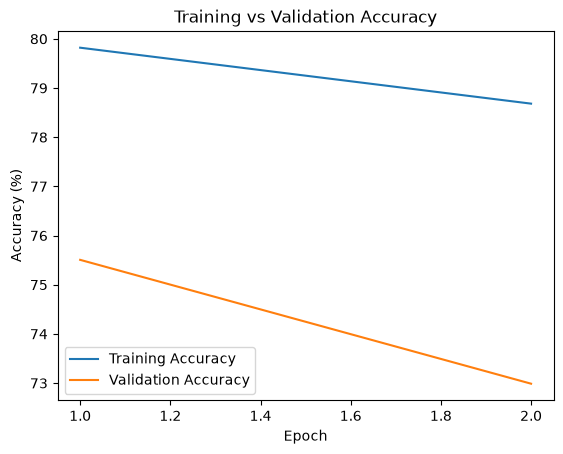

In [22]:

#make plots
epochs = range(1, len(train_accuracies) + 1)

plt.plot(epochs, train_accuracies, label="Training Accuracy")
plt.plot(epochs, val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.show()